# Decoder-Only Transformer — character-level, on Tiny Shakespeare
### Practical Approach to Deep Learning — Assignment, Part 2

A GPT-style decoder-only Transformer built from primitives — no `nn.MultiheadAttention`, no `nn.TransformerDecoder`. Every matrix multiply in the attention mechanism is explicit, so you can point at the exact line that implements $QK^T/\sqrt{d_k}$.

## 1. What a decoder-only Transformer is doing

The model learns $p(x_t \mid x_{<t})$ — the distribution over the next token given everything before it — and is trained by maximizing that likelihood over every position in every training sequence at once (cross-entropy against the actual next token). There's no separate encoder; the same stack reads the input and, because of the causal mask introduced below, position $t$ only ever attends to positions $\le t$. That's what makes one forward pass able to produce a training signal for *every* position in the sequence simultaneously, even though generation later happens one token at a time.

We work at the **character level** here (predict the next character, not the next word/subword), which avoids needing a separate tokenizer/BPE library and keeps the vocabulary tiny (~65 symbols for Shakespeare) — the architecture itself doesn't care what the tokens are.

## 2. Token + positional embeddings

`nn.Embedding(vocab_size, n_embd)` gives each token id a learned vector. On its own, that's all a Transformer would ever see — and self-attention (below) has no built-in notion of order, it treats the sequence as an unordered set of positions until you inject position information explicitly.

We use **learned** positional embeddings: a second `nn.Embedding(block_size, n_embd)` table with one learned vector per absolute position $0 \dots \text{block\_size}-1$, added elementwise to the token embedding. (The alternative — **sinusoidal** embeddings, fixed sine/cosine functions of position at different frequencies rather than learned — is what the brief also allows; learned is simpler to implement correctly and works fine at this scale.)

## 3. Causal multi-head self-attention, derived

For each position, three learned linear projections of the *same* input sequence produce a query, key, and value vector — "self"-attention because Q, K and V all come from the same source, unlike the encoder-decoder attention in the original Transformer.

$$
\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V
$$

**Why $QK^\top$:** the dot product between position $i$'s query and position $j$'s key measures how relevant $j$ is to $i$ — large when the vectors are aligned, near zero when unrelated. Doing this for every pair gives a $T\times T$ matrix of raw relevance scores.

**Why divide by $\sqrt{d_k}$:** if $Q$ and $K$'s entries are roughly unit-variance, the dot product of two $d_k$-dimensional vectors has variance that grows linearly with $d_k$. Left unscaled, the softmax inputs grow with model size and saturate — pushing the softmax into a near-one-hot regime with vanishingly small gradients almost everywhere. Dividing by $\sqrt{d_k}$ keeps the pre-softmax variance roughly constant regardless of head size.

**Why the mask $M$:** $M$ is $0$ on and below the diagonal and $-\infty$ above it, so `softmax` assigns *exactly zero* weight to any future position — enforced numerically (adding $-\infty$ before softmax, not just training the model and hoping it learns to ignore the future). Without this, the model could trivially "cheat" during training by reading the answer it's supposed to predict.

**Why multiple heads:** rather than one attention computation over the full $d_{\text{model}}$ dimensions, split into $n_{\text{head}}$ parallel attention computations, each over a $d_k = d_{\text{model}}/n_{\text{head}}$ slice. Different heads are free to specialize — e.g. one attending mostly to the immediately preceding character, another picking up longer-range structure — then all heads' outputs are concatenated and linearly projected back to $d_{\text{model}}$.

The code below implements this with a single combined linear layer producing $Q$, $K$, $V$ together (one matmul instead of three), then reshapes into heads — mathematically identical to separate per-head projections, just the standard, more efficient way to write it.

## 4. The Transformer block: Pre-LN, residual, FFN

$$
x \leftarrow x + \text{Attention}(\text{LayerNorm}(x)), \qquad x \leftarrow x + \text{FFN}(\text{LayerNorm}(x))
$$

**Pre-LN** means LayerNorm is applied *before* each sub-layer, not after (as in the original 2017 Transformer). This keeps the residual path a clean, unnormalized identity connection from input to output — the normalization only happens inside the branch being added, not on the path the gradient flows straight through — which in practice gives noticeably more stable gradients through a deep stack.

**Residual connections** (the `x + ...`) let gradients skip straight through each block via simple addition, the same reasoning as in ResNets — crucial once you stack several of these blocks.

**The FFN** is a position-wise two-layer MLP (same weights applied independently to every position), expanding to $4\times$ the model width and projecting back down, with a **GELU** activation rather than ReLU — smoother, and it lets small negative inputs through rather than hard-zeroing them, which is the standard choice in Transformer FFNs.

## 5. Optimization: mixed precision, selective weight decay, warmup + cosine decay

**Mixed precision.** Running the forward pass in fp16 instead of fp32 roughly halves memory and can be substantially faster on tensor-core GPUs — but fp16 has a much smaller dynamic range, so small gradient values can underflow to zero during backprop. `autocast` automatically runs eligible ops in fp16 while keeping numerically sensitive ops (softmax, loss) in fp32 internally; `GradScaler` compensates for the underflow risk by scaling the loss *up* before `.backward()` (so small gradients become representable in fp16) and unscaling before the optimizer actually applies them.

> The brief names `torch.cuda.amp.autocast`/`GradScaler` — recent PyTorch has deprecated those specific spellings (they still work, just emit a `FutureWarning`) in favour of the device-generic `torch.amp.autocast('cuda', ...)` / `torch.amp.GradScaler('cuda', ...)`, which is what's used below. Functionally identical; worth a one-line mention in your report that you're aware the API moved — that's a genuine-understanding signal, not just a cosmetic choice. Colab's free-tier GPU (T4) doesn't support bf16 efficiently, so we default to fp16 + `GradScaler`; on an Ampere-or-newer GPU you could switch `amp_dtype` to `torch.bfloat16`, which doesn't strictly need the scaler (bf16 has fp32-like dynamic range) but keeping the scaler enabled is harmless either way.

**Selective weight decay.** Weight decay shrinks parameters toward zero to reduce overfitting — sensible for the large 2-D weight matrices in `Linear`/`Embedding` layers, which carry most of the model's representational capacity. It's not applied to 1-D parameters (biases, and LayerNorm's learned gain/shift): a LayerNorm's gain controls the *scale* of activations rather than fitting the data in the sense weight decay is meant to counteract, and biases have essentially no capacity to overfit on their own. The code below sorts every parameter into one of two optimizer groups by `param.dim()`.

**Warmup + cosine decay.** Starting with a very low learning rate and ramping it up linearly avoids a large, destabilizing update at step one, when Adam's per-parameter second-moment estimates are still unreliable and the random initialization is far from anything good. After warmup, `CosineAnnealingLR` smoothly decays the LR along a cosine curve toward (near) zero by the end of training — empirically this tends to land at a better final loss than a constant or step-decayed rate.

## 6. Generation strategies

- **Greedy** — always take the single highest-probability next token (`argmax`). Deterministic, but repetitive and unable to recover from an early bad choice, since there's no mechanism to reconsider.
- **Temperature** — divide logits by $T$ before softmax. $T<1$ sharpens the distribution (more conservative, → greedy as $T\to 0$); $T>1$ flattens it (more diverse, risks incoherence as $T$ grows); $T=1$ leaves the model's learned distribution unchanged.
- **Top-k** — zero out every logit except the $k$ largest before sampling. Keeps some randomness (unlike greedy) while ruling out the wildly implausible long tail that pure temperature sampling can still occasionally hit.

### Explanation of Imports and Environment Setup
In this first code cell:
- **`math`** and **`torch`** are imported to provide core mathematical operations and the PyTorch tensor framework.
- **`torch.nn`** (`nn`) and **`torch.nn.functional`** (`F`) contain the building blocks for neural networks (layers, loss functions, activation functions).
- **`matplotlib.pyplot`** is used for plotting loss curves and learning rates later.
- **`torch.manual_seed(42)`** ensures reproducibility by initializing the random number generator with a fixed seed.
- **`device` detection** checks for an available CUDA-enabled GPU. Training on a GPU is significantly faster for neural networks.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


### Explanation of Hyperparameters
The cell below defines the configuration parameters for both the model architecture and the training pipeline:
- **`N_EMBD` (128)**: The size of the vector representations (embeddings) for characters and positions.
- **`N_HEAD` (4)**: The number of self-attention heads. Each head operates on a subspace of dimension `N_EMBD // N_HEAD = 32`.
- **`N_LAYER` (4)**: The number of transformer blocks stacked on top of each other.
- **`BLOCK_SIZE` (128)**: The maximum sequence length (context window) that the model can process at once.
- **`DROPOUT` (0.1)**: The probability of randomly zeroing out elements during training to prevent overfitting.
- **`BATCH_SIZE` (64)**: The number of sequences processed in parallel in a single training step.
- **`MAX_ITERS` (3000)**: Total number of training optimization steps.
- **`WARMUP_ITERS` (100)**: The number of initial steps during which the learning rate linearly ramps up.
- **`LEARNING_RATE` (3e-4)**: The peak learning rate for the AdamW optimizer.
- **`WEIGHT_DECAY` (0.1)**: L2 regularization strength applied to weights.
- **`USE_AMP` & `AMP_DTYPE`**: Enables Automatic Mixed Precision (FP16) on GPU to reduce memory consumption and accelerate computation.

In [2]:
# --- model size: deliberately small ("miniature", per the brief) ---
N_EMBD = 128
N_HEAD = 4          # head_dim = N_EMBD // N_HEAD = 32
N_LAYER = 4
BLOCK_SIZE = 128    # context length
DROPOUT = 0.1

# --- training ---
BATCH_SIZE = 64
MAX_ITERS = 3000
WARMUP_ITERS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1
EVAL_INTERVAL = 250
EVAL_ITERS = 50     # batches averaged per validation estimate

USE_AMP = (device == "cuda")
AMP_DTYPE = torch.float16

### Explanation of Data Loading and Tokenization
The cell below manages the dataset lifecycle:
1. **Downloading**: Fetches the raw text of Tiny Shakespeare via a HTTP requests.
2. **Vocabulary**: Identifies all unique characters (65 in this dataset) to define the character-level vocabulary.
3. **Encoding/Decoding**: Creates mapping dictionaries (`stoi` and `itos`) to convert characters to integers and vice versa.
4. **Train/Val Split**: Converts the entire text into a PyTorch tensor of integers, splitting 90% for training and 10% for validation.
5. **`get_batch`**: Randomly samples a batch of sequences. For any starting index `i`, the input sequence `x` is the text slice `[i : i+BLOCK_SIZE]`, and the target sequence `y` is `[i+1 : i+1+BLOCK_SIZE]` (which is `x` shifted right by one character, serving as the ground truth for next-character prediction).

In [3]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url, timeout=30).text
print(f"{len(text)} characters")

chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"vocab_size = {vocab_size}")

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"train: {len(train_data)} tokens | val: {len(val_data)} tokens")

def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack([d[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([d[i + 1:i + 1 + BLOCK_SIZE] for i in ix])   # y is x shifted one position to the right
    return x.to(device), y.to(device)

1115394 characters
vocab_size = 65
train: 1003854 tokens | val: 111540 tokens


### Explanation of Causal Self-Attention
The cell below implements the multi-head causal self-attention mechanism from scratch:
- **`qkv_proj`**: Projects the input representation into Query (Q), Key (K), and Value (V) tensors simultaneously in a single matrix multiplication.
- **Heads Splitting**: Reshapes and transposes Q, K, and V tensors so that the attention scores are computed independently for each of the `N_HEAD` heads.
- **Scaled Dot-Product**: Multiplies Queries by Keys ($QK^T$), scales by $1 / \sqrt{d_k}$ to prevent gradient saturation, and applies a causal mask (`causal_mask`). This mask sets all future tokens to $-\infty$ so that the softmax function assigns them zero probability, preventing the model from "looking ahead".
- **Aggregation & Projection**: The resulting attention weights are multiplied by the values (V), reshaped back to the original shape, and projected through `out_proj` with dropout.

In [5]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head

        self.qkv_proj = nn.Linear(n_embd, 3 * n_embd)   # combined Q,K,V projection -- one matmul instead of three
        self.out_proj = nn.Linear(n_embd, n_embd)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        # causal mask, precomputed once: 1s on/below the diagonal, 0s above.
        # Registered as a buffer (not a Parameter) so .to(device) moves it but the optimizer never touches it.
        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("causal_mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv_proj(x)              # (B,T,3C)
        q, k, v = qkv.split(C, dim=2)       # each (B,T,C)

        # split into heads: (B,T,C) -> (B,T,nh,hd) -> (B,nh,T,hd)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        # scaled dot-product attention scores: (B,nh,T,hd) @ (B,nh,hd,T) -> (B,nh,T,T)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.causal_mask[:, :, :T, :T] == 0, float("-inf"))  # -inf strictly above the diagonal
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        out = att @ v                                     # (B,nh,T,T) @ (B,nh,T,hd) -> (B,nh,T,hd)
        out = out.transpose(1, 2).contiguous().view(B, T, C)   # merge heads back: (B,nh,T,hd) -> (B,T,C)
        return self.resid_dropout(self.out_proj(out))

### Explanation of Feed-Forward Network and Transformer Block
The cell below implements the remaining components of the Transformer block architecture:
1. **`FeedForward`**: A position-wise multi-layer perceptron that expands the feature size to $4 \times$ `n_embd`, applies a non-linear GELU activation, projects it back to `n_embd`, and applies dropout.
2. **`TransformerBlock`**: Stacks the multi-head self-attention module and the feed-forward network with **Pre-Layer Normalization (Pre-LN)** and residual connections. The LayerNorm is applied to the input *before* sending it to the sub-layers, and the original input is added back afterwards (`x = x + sublayer(LN(x))`), stabilizing the gradient flow through deep networks.

In [6]:
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = FeedForward(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # Pre-LN: normalize BEFORE the sub-layer, add its output as a residual
        x = x + self.ffn(self.ln2(x))
        return x

### Explanation of the MiniGPT Model and Generation Engine
The cell below defines the core `MiniGPT` model:
- **Embeddings**: Utilizes learned token embeddings (`token_emb`) and learned positional embeddings (`pos_emb`) up to `BLOCK_SIZE`.
- **Weight Tying**: Shares the weights between the input token embedding layer and the final output projection head (`self.head.weight = self.token_emb.weight`) to reduce parameter count and improve regularization.
- **Forward Pass**: Computes embeddings, adds them together, passes them through the stack of Transformer Blocks, applies final layer normalization, and projects to vocabulary logits. If targets are provided, it calculates the cross-entropy loss.
- **`generate`**: Implements greedy, temperature-scaled, and top-k sampling strategies. It iteratively passes the sliding context window to the model, retrieves the distribution of the final predicted character, samples from it, and appends it to the running sequence.

In [7]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([TransformerBlock(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)
        self.head.weight = self.token_emb.weight   # weight tying: shares params between input embedding and output projection

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_emb(idx)                                     # (B,T,C)
        pos = self.pos_emb(torch.arange(T, device=idx.device))        # (T,C), broadcasts over the batch
        x = self.drop(tok + pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)   # (B,T,vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, do_sample=True):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]     # crop context to the last block_size tokens
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]                 # only the next-token distribution matters here

            if not do_sample:
                next_id = torch.argmax(logits, dim=-1, keepdim=True)     # greedy decoding
            else:
                logits = logits / temperature
                if top_k is not None:
                    v, _ = torch.topk(logits, top_k)
                    logits[logits < v[:, [-1]]] = float("-inf")          # zero out everything outside the top-k
                probs = F.softmax(logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_id], dim=1)
        return idx

### Explanation of Optimizer, Learning Rate Schedulers, and AMP
The cell below configures the training optimization process:
- **Model Instantiation**: Moves the created `MiniGPT` model to the GPU/CPU device.
- **`configure_optimizer`**: Implements selective weight decay by separating 2D/multi-dimensional weights (which undergo weight decay to prevent overfitting) from 1D biases and LayerNorm parameters (which are excluded from weight decay).
- **Schedulers**: Combines a linear warmup scheduler (which gradually ramps up learning rate to prevent early training instability) and a Cosine Annealing scheduler (which smoothly decays the learning rate to near-zero) using `SequentialLR`.
- **`GradScaler`**: Manages loss scaling for mixed precision training, protecting against gradient underflow when using FP16.

In [8]:
model = MiniGPT(vocab_size, N_EMBD, N_HEAD, N_LAYER, BLOCK_SIZE, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params/1e6:.2f}M parameters")

def configure_optimizer(model, weight_decay, learning_rate):
    decay, no_decay = [], []
    for p in model.parameters():
        if not p.requires_grad:
            continue
        (decay if p.dim() >= 2 else no_decay).append(p)   # weight matrices vs. biases/LayerNorm params
    groups = [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]
    print(f"decayed params: {sum(p.numel() for p in decay):,} | non-decayed: {sum(p.numel() for p in no_decay):,}")
    return torch.optim.AdamW(groups, lr=learning_rate, betas=(0.9, 0.95))

optimizer = configure_optimizer(model, WEIGHT_DECAY, LEARNING_RATE)

warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=WARMUP_ITERS)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_ITERS - WARMUP_ITERS)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_ITERS])

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

0.82M parameters
decayed params: 811,136 | non-decayed: 6,912


### Explanation of Loss Estimation Helper
The cell below defines a function to compute stable, non-noisy validation and training losses:
- **`@torch.no_grad()`** disables gradient calculations to save memory and processing time during evaluation.
- **`model.eval()`** and **`model.train()`** toggle the model state to correctly handle dropout layers (disabled during evaluation, active during training).
- **Averaging**: It averages the loss over `EVAL_ITERS` (50) random batches to provide a smooth, low-variance estimate of performance on both training and validation splits.

In [9]:
@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            xb, yb = get_batch(split)
            with torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

### Explanation of the Training Loop
The cell below executes the primary training loop:
- It runs for `MAX_ITERS` iterations.
- **Forward Pass**: Fetches a training batch and passes it to the model under `torch.amp.autocast` to execute operations in half-precision (FP16).
- **Backward Pass**: Scales the loss using `scaler.scale(loss)`, computes gradients with `.backward()`, and updates the weights using the scaled optimizer steps.
- **LR Step**: Updates the learning rate according to the warmup and cosine decay scheduler.
- **Evaluation**: Periodically calls `estimate_loss()` to track, log, and store training progress in the `history` dictionary.

In [10]:
history = {"iter": [], "train_loss": [], "val_loss": [], "lr": []}

for it in range(1, MAX_ITERS + 1):
    xb, yb = get_batch("train")

    with torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
        _, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    if it % EVAL_INTERVAL == 0 or it == 1:
        losses = estimate_loss()
        history["iter"].append(it)
        history["train_loss"].append(losses["train"])
        history["val_loss"].append(losses["val"])
        history["lr"].append(scheduler.get_last_lr()[0])
        print(f"iter {it:5d} | train {losses['train']:.3f} | val {losses['val']:.3f} | lr {history['lr'][-1]:.2e}")

iter     1 | train 85.895 | val 85.735 | lr 5.97e-06
iter   250 | train 2.804 | val 2.833 | lr 2.98e-04
iter   500 | train 2.581 | val 2.608 | lr 2.86e-04
iter   750 | train 2.506 | val 2.533 | lr 2.64e-04
iter  1000 | train 2.470 | val 2.491 | lr 2.34e-04
iter  1250 | train 2.438 | val 2.460 | lr 1.98e-04
iter  1500 | train 2.404 | val 2.424 | lr 1.58e-04
iter  1750 | train 2.379 | val 2.403 | lr 1.18e-04
iter  2000 | train 2.361 | val 2.384 | lr 7.97e-05
iter  2250 | train 2.343 | val 2.365 | lr 4.68e-05
iter  2500 | train 2.332 | val 2.359 | lr 2.15e-05
iter  2750 | train 2.331 | val 2.353 | lr 5.47e-06
iter  3000 | train 2.324 | val 2.350 | lr 0.00e+00


### Explanation of Metrics Visualization
The cell below plots the performance metrics collected during training:
- **Subplot 1 (Loss)**: Shows the training and validation cross-entropy loss curves. A widening gap between the two curves indicates overfitting.
- **Subplot 2 (Learning Rate)**: Displays the learning rate across iterations, visually demonstrating the initial linear warmup and the subsequent smooth cosine decay curve.

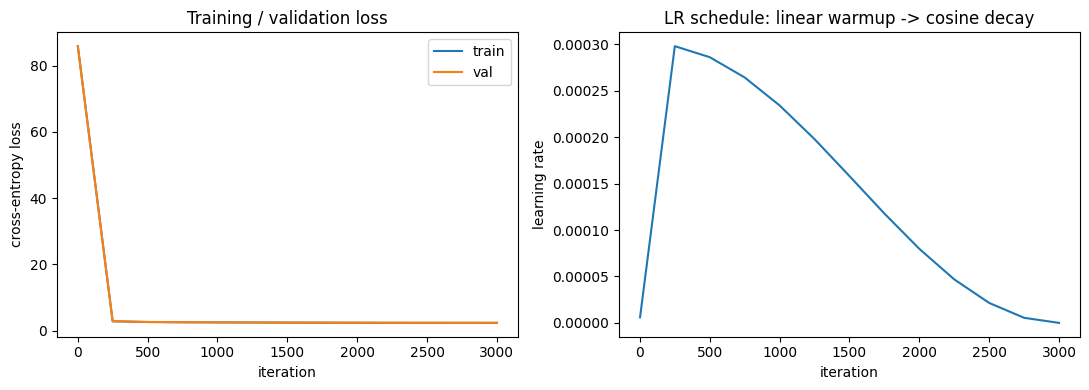

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["iter"], history["train_loss"], label="train")
axes[0].plot(history["iter"], history["val_loss"], label="val")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("cross-entropy loss"); axes[0].legend()
axes[0].set_title("Training / validation loss")

axes[1].plot(history["iter"], history["lr"])
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("learning rate")
axes[1].set_title("LR schedule: linear warmup -> cosine decay")

plt.tight_layout()
plt.show()

# If train loss keeps falling while val loss flattens or rises, that's overfitting

### Explanation of Text Generation Demonstration
The cell below samples characters from the trained model starting with the prompt `"ROMEO:"` using four distinct generation strategies:
1. **Greedy**: Always picks the character with the absolute highest probability. Highly deterministic, but prone to repeating patterns.
2. **Temperature = 0.8**: Introduces controlled randomness. Lower temperatures make predictions more focused.
3. **Temperature = 1.2**: Increases randomness significantly, producing more creative yet potentially nonsensical or noisy sequences.
4. **Top-k = 20 with Temperature = 0.8**: Restricts sampling to only the top 20 most probable characters, maintaining natural diversity while filtering out highly implausible tokens.

In [12]:
context = torch.tensor([encode("ROMEO:")], dtype=torch.long, device=device)

print("=== Greedy ===")
out = model.generate(context, max_new_tokens=200, do_sample=False)
print(decode(out[0].tolist()))

print("\n=== Temperature = 0.8 ===")
out = model.generate(context, max_new_tokens=200, temperature=0.8)
print(decode(out[0].tolist()))

print("\n=== Temperature = 1.2 (more random) ===")
out = model.generate(context, max_new_tokens=200, temperature=1.2)
print(decode(out[0].tolist()))

print("\n=== Top-k = 20, temperature = 0.8 ===")
out = model.generate(context, max_new_tokens=200, temperature=0.8, top_k=20)
print(decode(out[0].tolist()))

=== Greedy ===
ROMEO:
An the that the the the the the the the the the there the the the the the the the thave the
Tour tousthe the the the se there t the the the the there the myous the the t the the there the the fou the

=== Temperature = 0.8 ===
ROMEO:
Ank ve ale kealin garat stouby, the thars beceand a cco tord,
To sord, ben thant, iress tes mersthfreave hes te s fobed t hie gundathesthe marad molat
Whenge lfr pero they my?

JUKEORARilicod:
Hou t 

=== Temperature = 1.2 (more random) ===
ROMEO:
Thy hing sutht n nou bougend de d mo;
Lentigs. I hex t -whurin rilll t lcowis ighedomer t sill,
R: jus r' ig r'da I t oungh e ingh ch, oriculdsowharenig.


KI w RUKIUmatmerizAUVANO:
Soo OSY,
I byos I

=== Top-k = 20, temperature = 0.8 ===
ROMEO:
Ang stith ther omy gerand herup bors?

Ange wsis hell ay nd nellou d and s ted frealond an the,
Toun ther a s thaiamyore, be nis wif d.

Windee whelingo chowhan:
Tinor be ise d n, arerd ll bloothar i
